In [1]:
# %pip install resource
# %python.exe -m pip install --upgrade pip

import numpy as np
import keras
import keras_cv
from keras_cv import visualization

In [2]:
# List available presets for RetinaNet
print(keras_cv.models.RetinaNet.presets.keys())

# Use a valid preset identifier from the list
pretrained_model = keras_cv.models.RetinaNet.from_preset(
    "retinanet_resnet50_pascalvoc",
    bounding_box_format="xywh"
)

dict_keys(['resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152', 'resnet18_v2', 'resnet34_v2', 'resnet50_v2', 'resnet101_v2', 'resnet152_v2', 'mobilenet_v3_small', 'mobilenet_v3_large', 'csp_darknet_tiny', 'csp_darknet_s', 'csp_darknet_m', 'csp_darknet_l', 'csp_darknet_xl', 'efficientnetv1_b0', 'efficientnetv1_b1', 'efficientnetv1_b2', 'efficientnetv1_b3', 'efficientnetv1_b4', 'efficientnetv1_b5', 'efficientnetv1_b6', 'efficientnetv1_b7', 'efficientnetv2_s', 'efficientnetv2_m', 'efficientnetv2_l', 'efficientnetv2_b0', 'efficientnetv2_b1', 'efficientnetv2_b2', 'efficientnetv2_b3', 'densenet121', 'densenet169', 'densenet201', 'efficientnetlite_b0', 'efficientnetlite_b1', 'efficientnetlite_b2', 'efficientnetlite_b3', 'efficientnetlite_b4', 'yolo_v8_xs_backbone', 'yolo_v8_s_backbone', 'yolo_v8_m_backbone', 'yolo_v8_l_backbone', 'yolo_v8_xl_backbone', 'vitdet_base', 'vitdet_large', 'vitdet_huge', 'videoswin_tiny', 'videoswin_small', 'videoswin_base', 'resnet50_imagenet', 'resnet50_v

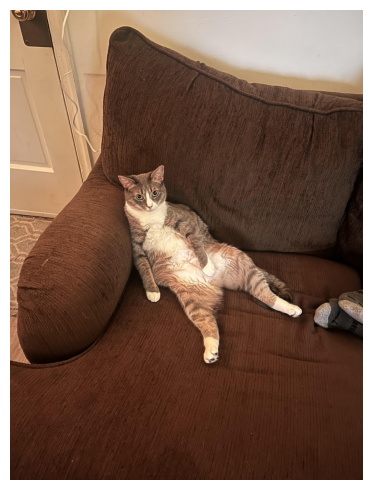

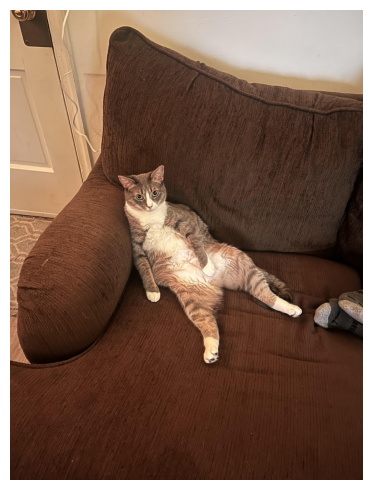

In [3]:
url = 'https://i.redd.it/twpfhcw58xgb1.jpg'
filepath = keras.utils.get_file(origin = url)
image = keras.utils.load_img(filepath)
image = np.array(image)

h, w, c = image.shape
batch = image.reshape(1, h, w, c)

visualization.plot_image_gallery(
    batch,
    value_range=(0, 255),
    rows=1,
    cols=1,
    scale=5
)

In [4]:
inference_resizing = keras_cv.layers.Resizing(
    height=640,
    width=640,
    pad_to_aspect_ratio=True,
    bounding_box_format="xywh",
)

In [ ]:
image_batch = inference_resizing(batch)

label_names = [
    "aeroplane",
    "bicycle",
    "bird",
    "boat",
    "bottle",
    "bus",
    "car",
    "cat",
    "chair",
    "cow",
    "diningtable",
    "dog",
    "horse",
    "motorbike",
    "person",
    "pottedplant",
    "sheep",
    "sofa",
    "train",
    "tvmonitor"
]

class_mapping = {k: v for k, v in enumerate(label_names)}

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


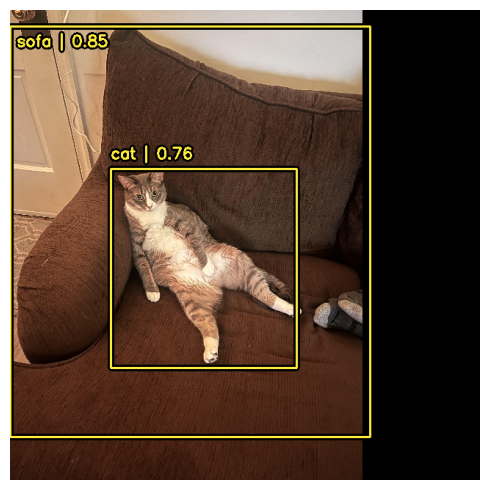

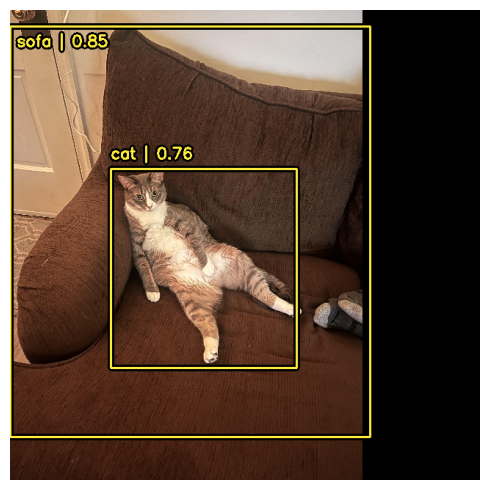

In [ ]:
y_pred = pretrained_model.predict(image_batch)

# Install the required package
# %pip install opencv-python
# %pip install --upgrade --force-reinstall opencv-python

visualization.plot_bounding_box_gallery(
    images=image_batch,
    value_range=(0, 255),
    rows=1,
    cols=1,
    y_pred=y_pred,
    scale=5,
    font_scale=0.7,
    bounding_box_format="xywh",
    class_mapping=class_mapping
)